In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
#MemorySaver se jo bhi conversation hai vo RAM me store karta hai.

In [ ]:
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [21]:
from langgraph.graph import add_messages


class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [22]:
def chat_node(state: ChatState):
    #take user query as input
    messages = state['messages']
    
    #send to llm
    response = llm.invoke(messages)

    #response store state
    return {'messages': [response]}

In [23]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)


In [17]:
initial_state = {
    'messages':[HumanMessage(content="What is LangGraph?")]
}

chatbot.invoke(initial_state)['messages'][-1]

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [25]:
thread_id = '1'


while True:
    user_message = input('type here:')
    print('user_message:', user_message)

    if user_message.strip().lower() in ['exit', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print('AI:', response['messages'][-1].content)

user_message: hi my name is ninad
AI: Hi Ninad, it's nice to meet you. Is there something I can help you with or would you like to chat?
user_message: what is my name
AI: Your name is Ninad.
user_message: what is 10+23
AI: 10 + 23 = 33.
user_message: now add 30 to result
AI: We had 33 as the result earlier. 

33 + 30 = 63.
user_message: my surname is uttarwar
AI: So, your full name is Ninad Uttwar.
user_message: correct, exit
AI: It was nice chatting with you, Ninad Uttwar. Goodbye!
user_message: exit 


In [26]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is ninad', additional_kwargs={}, response_metadata={}, id='c5237f68-ca5b-4a71-990b-501230f5ea5f'), AIMessage(content="Hi Ninad, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.062112347, 'completion_tokens_details': None, 'prompt_time': 0.017407226, 'prompt_tokens_details': None, 'queue_time': 1.607410373, 'total_time': 0.079519573}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6403-14f7-74e0-8f0c-67bd36f90845-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}), HumanMessage(content='what is my name', additional_kwargs={}

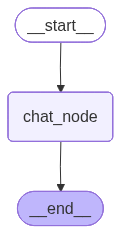

In [ ]:
chatbot